<a href="https://colab.research.google.com/github/alex-degarate/DAnalytics/blob/main/anexo/anexo5-13dic-0340.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

================================================================================
# ANEXO 5                               
USANDO df_ventas7 y df_producto6k

## PROBABLES MEJORAS A FUTURO        version 3 / 13-dic 03:40


### *Trabajo en curso*

1  

2  

Se observó que:
1. Las ventas contienen productos con la misma denominación, sin ninguna id como para identificarlos. Pertenecen a distintas ventas individuales y tienen distinto precio.

2. Por tal razón es dificil hacer una evaluación seria del resultado de la campaña publicitaria, porque corresponde a distintos productos agrupados, con precio sin adjudicar.

3. La campaña de marketing posee el costo publicitario por producto (generico/agregado) pero no hay como relacionarlo con el costo_unitario, ni con el precio_venta

4. Sacar un precio_promedio, no estoy seguro que sirva mucho, porque la venta podria haberse hecho a un valor menor que el precio_unitario_promedio, debido a la gran dispersión de precios

Hemos visto que para el producto "Adorno de pared", los precios estan distribuidos en 3 segmentos o rangos, la idea es hacer un promedio por rango y
luego renombrar los productos segun el rango, por ej:
"Adorno de pared" => "Adorno de pared R1"

De esta manera en lugar de tener 100 productos genericos los tendriamos divididos por rango de precios y con un nuevo nombre_producto y un nuevo id_producto que los represente
  
.  




ESTE ES EL ENFOQUE QUE VOY A TRATAR DE DESARROLLAR

##S-1  df_producto
Contiene id_producto Unico para un "producto" clasificado por rangos: R1,
R2 y R3 porque los precios estan diferenciados  

Existe 2 denominaciones del producto:  
a) una generica, ej: "Adorno de pared"   
b) otra unica => "Adorno de pared-R1" con  su id asociado: 101  

Este DF contiene ademas:  
'rango': 'R1', 'R2', 'R3', respectivamente  
'media_rango': el valor promedio de ese producto en ese rango de precios  
'precio_rango': el rango de precio unitario para el producto en ese rango



##S-2
Los productos en df_ventas se vinculan por ID Unico, presente en ambas tablas  
Es opcional el nombre unico y estoy evaluando si lo pongo o no

Se agrego ["id_cat"] numerica para facilitar las operaciones y se mantiene["categoria"] para ser convertida como "category" de ser necesaria o borrada

Tambien se reordenaron los campos de los DF

In [32]:
import pandas as pd

# habilito mostrar hasta 100 filas por DF
pd.set_option('display.max_rows', 100)

# Import dataset ventas final
url = "https://github.com/alex-degarate/DAnalytics/raw/refs/heads/main/anexo/"


In [59]:
df_aLista_prod = pd.read_csv( url + "df_aLista_prod.csv", index_col=0)
#df_aLista_prod

In [137]:
# Import pre dataset ventas_market
df_ventas_market = pd.read_csv( url + "ventas_market.csv", index_col=0)

In [ ]:
# reindexa dejando el antiguo index
#df_ventas_market = df_ventas_market.reset_index()

# reindexa borrando el antiguo index
#df_ventas_market = df_ventas_market.reset_index( drop=True)

In [154]:
# Ensure date columns are in datetime format
df_ventas_market['fecha_venta'] = pd.to_datetime(df_ventas_market['fecha_venta'].dt.date) #, format="%d/%m/%Y")


In [180]:
df_ventas_market['fecha_venta'].dtype

dtype('<M8[ns]')

In [155]:
df_ventas_market.info()
df_ventas_market.head()

<class 'pandas.core.frame.DataFrame'>
Index: 2998 entries, 1476 to 744
Data columns (total 15 columns):
 #   Column        Non-Null Count  Dtype         
---  ------        --------------  -----         
 0   id_venta      2998 non-null   int64         
 1   id_prod       2998 non-null   int64         
 2   id_producto   2998 non-null   int64         
 3   producto      2998 non-null   object        
 4   rango         2998 non-null   object        
 5   precio_unit   2998 non-null   float64       
 6   cantidad      2998 non-null   int64         
 7   fecha_venta   2998 non-null   datetime64[ns]
 8   id_cat        2998 non-null   int64         
 9   categoria     2998 non-null   object        
 10  precio_rango  2998 non-null   object        
 11  dentro_camp   2998 non-null   int64         
 12  id_camp       2998 non-null   int64         
 13  canal         0 non-null      float64       
 14  costo_mrkt    0 non-null      float64       
dtypes: datetime64[ns](1), float64(3), int64(7

,id_venta,id_prod,id_producto,producto,rango,precio_unit,cantidad,fecha_venta,id_cat,categoria,precio_rango,dentro_camp,id_camp,canal,costo_mrkt
1476,410,100,103,Adorno de pared,R3,109.64,3,2024-06-21,1,Decoración,91-120,0,0,NaN,NaN
2426,620,100,103,Adorno de pared,R3,92.16,4,2024-10-21,1,Decoración,91-120,0,0,NaN,NaN
697,780,100,102,Adorno de pared,R2,79.13,7,2024-03-21,1,Decoración,66-91,0,0,NaN,NaN
255,50,100,102,Adorno de pared,R2,83.10,5,2024-01-31,1,Decoración,66-91,0,0,NaN,NaN
112,260,100,103,Adorno de pared,R3,101.48,9,2024-01-15,1,Decoración,91-120,0,0,NaN,NaN


In [160]:
# Import dataset marketing
df_marketing = pd.read_csv( url + "df_marketing8.csv", index_col=0)


In [165]:
df_marketing['fecha_ini'] = pd.to_datetime(df_marketing['fecha_ini'])
df_marketing['fecha_fin'] = pd.to_datetime(df_marketing['fecha_fin'])


In [169]:
df_marketing['fecha_ini'] = pd.to_datetime(df_marketing['fecha_ini'].dt.date)
df_marketing['fecha_fin'] = pd.to_datetime(df_marketing['fecha_fin'].dt.date)


In [ ]:
#df_marketing['fecha_ini'] = pd.to_datetime(df_marketing['fecha_ini'], format="%d/%m/%Y")
#df_marketing['fecha_fin'] = pd.to_datetime(df_marketing['fecha_fin'], format="%d/%m/%Y")

In [167]:
df_marketing.info()


<class 'pandas.core.frame.DataFrame'>
Index: 90 entries, 0 to 89
Data columns (total 10 columns):
 #   Column      Non-Null Count  Dtype         
---  ------      --------------  -----         
 0   id_camp     90 non-null     int64         
 1   producto    90 non-null     object        
 2   canal       90 non-null     object        
 3   costo_mrkt  90 non-null     float64       
 4   id_canal    90 non-null     int64         
 5   fecha_ini   90 non-null     datetime64[ns]
 6   fecha_fin   90 non-null     datetime64[ns]
 7   id_prod     90 non-null     int64         
 8   id_cat      90 non-null     int64         
 9   media_mrkt  90 non-null     float64       
dtypes: datetime64[ns](2), float64(2), int64(4), object(2)
memory usage: 7.7+ KB


In [168]:
df_marketing.head()

,id_camp,producto,canal,costo_mrkt,id_canal,fecha_ini,fecha_fin,id_prod,id_cat,media_mrkt
0,14,Adorno de pared,RRSS,4.16,1,2024-10-22,2024-12-21,100,1,4.683333
1,74,Adorno de pared,TV,4.81,2,2024-03-20,2024-05-03,100,1,4.683333
2,44,Adorno de pared,Email,5.08,3,2024-04-13,2024-05-10,100,1,4.683333
3,58,Alfombra,Email,4.25,1,2024-03-31,2024-05-05,110,1,5.820000
4,28,Alfombra,RRSS,5.82,2,2024-11-27,2025-01-08,110,1,5.820000


In [42]:
# Import dataset df_producto
df_producto = pd.read_csv( url + "df_producto7b.csv", index_col=0)

.  

=====

## Lista alfabetica de productos

In [215]:
df_aLista_prod

,Producto,Procesado,Count,id_prod
0,Adorno de pared,1,100,100
1,Alfombra,1,100,110
2,Aspiradora,1,100,120
3,Auriculares,1,143,130
4,Batidora,1,100,140
5,Cafetera,1,117,150
6,Candelabro,1,24,160
7,Consola de videojuegos,1,99,170
8,Cortinas,1,100,180
9,Cuadro decorativo,1,100,190


In [69]:
# Obtengo el codigo id_producto
#df_aLista_prod = pd.merge(df_aLista_prod, df_producto[['id_producto', 'producto_rango']], left_on='Producto', right_on='producto_rango', how='left')

# Drop the redundant 'producto_rango' column
#df_aLista_prod = df_aLista_prod.drop(columns=['producto_rango'])


In [ ]:
#df_aLista_prod.rename(columns={"id_producto": "id_prod"}, inplace=True)
#df_aLista_prod.head()

In [66]:
# Guardamos df_aLista_prod
#df_aLista_prod.to_csv('df_aLista_prod.csv')

### tengo que agregar a ventas_market los datos que faltan
AGREGO EL CONTADOR PARA CADA PRODUCTO, a df_aLista_prod

================================================================================


# PASOS PARA AUTOMATIZAR
## PARA TODOS LOS PRODUCTOS

### 1. Recorrer La lista de productos y df_ventas_market,
&emsp; si el 2do campo esta en cero significa que no fue procesado, 1=completo
lista_productos = [["Adorno de pared", 1]

### 2. OBTENER NOMBRE DEL PRODUCTO A PROCESAR


### 9. ACTUALIZAR df_ventas_market


## 2. OBTENER NOMBRE DEL PRODUCTO A PROCESAR

In [ ]:
# @title

nLenght = df_aLista_prod.shape[0]
'''
df_aLista_prod.iat[ 0, 1] = 1  # Adorno de pared
df_aLista_prod.iat[ 1, 1] = 1  # Alfombra
df_aLista_prod.iat[ 2, 1] = 1  # Aspiradora
df_aLista_prod.iat[ 3, 1] = 1  # Auriculares
df_aLista_prod.iat[ 4, 1] = 1  # Batidora
df_aLista_prod.iat[ 5, 1] = 1  # Cafetera
df_aLista_prod.iat[ 6, 1] = 1  # Candelabro
df_aLista_prod.iat[ 7, 1] = 1  # Consola de videojuegos
df_aLista_prod.iat[ 8, 1] = 1  # Cortinas
df_aLista_prod.iat[ 9, 1] = 1  # Cuadro decorativo
df_aLista_prod.iat[10, 1] = 1  # Cámara digital
df_aLista_prod.iat[11, 1] = 1  # Elementos de cerámica
df_aLista_prod.iat[12, 1] = 1  # Espejo decorativo
df_aLista_prod.iat[13, 1] = 1  # Freidora eléctrica
df_aLista_prod.iat[14, 1] = 1  # Heladera
df_aLista_prod.iat[15, 1] = 1  # Horno eléctrico
df_aLista_prod.iat[16, 1] = 1  # Jarrón decorativo
df_aLista_prod.iat[17, 1] = 1  # Laptop
df_aLista_prod.iat[18, 1] = 1  # Lavadora
df_aLista_prod.iat[19, 1] = 1  # Lámpara de mesa
df_aLista_prod.iat[20, 1] = 1  # Microondas
df_aLista_prod.iat[21, 1] = 1  # Parlantes Bluetooth
df_aLista_prod.iat[22, 1] = 1  # Plancha de vapor
df_aLista_prod.iat[23, 1] = 1  # Proyector
df_aLista_prod.iat[24, 1] = 1  # Rincón de plantas
df_aLista_prod.iat[25, 1] = 1  # Secadora
df_aLista_prod.iat[26, 1] = 1  # SmartWatch
df_aLista_prod.iat[27, 1] = 1  # Smartphone
df_aLista_prod.iat[28, 1] = 1  # Tablet
#df_aLista_prod.iat[29, 1] = 1  # Televisor

for i in range( nLenght):

    if df_aLista_prod.iat[i, 1] == 0:
       prod_actual = df_aLista_prod.iat[i, 0]      # nombre producto
       break

prod_actual = prod_actual
'''

num_elem = df_aLista_prod.iat[i, 2]
print(f"El primer item a procesar es {[i]}: {prod_actual}, tiene {num_elem} registros \n")


El primer item a procesar es [29]: Televisor, tiene 100 registros 



In [ ]:
df_aLista_prod.iat[19, 1] = 0 # Lámpara de mesa
display(df_aLista_prod)

# df_ventas_market ACTUAL

In [192]:
# agrego un campo nuevo
df_ventas_market['id_canal'] = 0

In [193]:
# pongo campo [canal]="no"y	[costo_mrkt] =0.00
len_ventas_mrkt = df_ventas_market.shape[0]
print(f"len_ventas_mrkt = {len_ventas_mrkt}")

for i in range( len_ventas_mrkt):
    df_ventas_market.iat[i, 11] = 0      # dentro_camp
    df_ventas_market.iat[i, 12] = 0      # id_camp
    df_ventas_market.iat[i, 13] = "no"   # canal
    df_ventas_market.iat[i, 14] = 0.00   # costo_mrkt
    df_ventas_market.iat[i, 15] = 0.00   # id_canal

len_ventas_mrkt = 2998


In [ ]:
#df_ventas_market.info()
df_ventas_market.head(50)

In [ ]:
df_ventas_market['fecha_venta'].tail(5)

In [204]:
import numpy as np

# Agregar a df_ventas_market los datos faltantes
cont_prod = 0  # i

rec_vent_mrkt = 0

#fecha_venta = df_ventas_market.iat[j, 7]  # fecha_venta posic 7
#print( f"fecha_venta {type(df_ventas_market.iat[j, 7])}")
#print( f"{type(df_ventas_market.iat[j, 7])}")

for i in range( 1):  #nLenght es el numero de productos

    prod_actual = df_aLista_prod.iat[i, 0]      # nombre producto

    # obtengo los 3 registros canal df_marketing de canales para prod_actual
    df_canal_mrkt = df_marketing[df_marketing['producto'] == prod_actual]

    display(df_canal_mrkt)
    print("\n\n")
    # si fecha_venta esta contenida entre fecha_ini y fecha_fin
    # obtengo campo id_camp, canal,  costo_mrkt

    # j= rec_vent_mrkt


    # Para todo df_ventas_mrkt ----------------------
    for j in range( len_ventas_mrkt): # len_ventas_mrkt

        #obtengo fecha venta
        fecha_venta = df_ventas_market.iat[j, 7]
        #print( f"{type(df_ventas_market.iat[j, 7])}")


        rec_mrkt = 0
        # para cada canal, chequeo el registro de ventas
        while rec_mrkt < 3:

              if (df_canal_mrkt.iat[rec_mrkt, 5]  <= fecha_venta) & (fecha_venta <=
                 df_canal_mrkt.iat[rec_mrkt, 6]):

                  # faltaria controlar las campañas que se solapen
                  df_canal_mrkt.iat[rec_mrkt, 0] # dentro_camp
                  df_ventas_market.iat[j,11] = 1
                  df_ventas_market.iat[j,12] = df_canal_mrkt.iat[rec_mrkt, 0] # id_camp
                  df_ventas_market.iat[j,13] = df_canal_mrkt.iat[rec_mrkt, 2] # canal
                  df_ventas_market.iat[j,14] = df_canal_mrkt.iat[rec_mrkt, 3] # costo_mrkt
                  df_ventas_market.iat[j,15] = df_canal_mrkt.iat[rec_mrkt, 4] # id_canal
                  print(f"  {rec_mrkt} encontrado ! id_camp: {df_canal_mrkt.iat[rec_mrkt, 0]}, canal: {df_canal_mrkt.iat[rec_mrkt, 2]}, costo_mrkt: {df_canal_mrkt.iat[rec_mrkt, 3]}")

              else:
                  # los valores por defecto ya estan puestos...
                  print(f"  {rec_mrkt} Not found ! => {fecha_venta}")

              rec_mrkt += 1

print("\nLlego al final!")

,id_camp,producto,canal,costo_mrkt,id_canal,fecha_ini,fecha_fin,id_prod,id_cat,media_mrkt
0,14,Adorno de pared,RRSS,4.16,1,2024-10-22,2024-12-21,100,1,4.683333
1,74,Adorno de pared,TV,4.81,2,2024-03-20,2024-05-03,100,1,4.683333
2,44,Adorno de pared,Email,5.08,3,2024-04-13,2024-05-10,100,1,4.683333


Se truncaron las últimas líneas 5000 del resultado de transmisión.
  0 Not found ! => 2024-06-26 00:00:00
  1 Not found ! => 2024-06-26 00:00:00
  2 Not found ! => 2024-06-26 00:00:00
  0 Not found ! => 2024-04-29 00:00:00
  1 encontrado ! id_camp: 74, canal: TV, costo_mrkt: 4.81
  2 encontrado ! id_camp: 44, canal: Email, costo_mrkt: 5.08
  0 Not found ! => 2024-05-20 00:00:00
  1 Not found ! => 2024-05-20 00:00:00
  2 Not found ! => 2024-05-20 00:00:00
  0 Not found ! => 2024-05-26 00:00:00
  1 Not found ! => 2024-05-26 00:00:00
  2 Not found ! => 2024-05-26 00:00:00
  0 Not found ! => 2024-04-30 00:00:00
  1 encontrado ! id_camp: 74, canal: TV, costo_mrkt: 4.81
  2 encontrado ! id_camp: 44, canal: Email, costo_mrkt: 5.08
  0 Not found ! => 2024-09-24 00:00:00
  1 Not found ! => 2024-09-24 00:00:00
  2 Not found ! => 2024-09-24 00:00:00
  0 encontrado ! id_camp: 14, canal: RRSS, costo_mrkt: 4.16
  1 Not found ! => 2024-10-27 00:00:00
  2 Not found ! => 2024-10-27 00:00:00
  0 Not fou

In [205]:
# Guardamos df_ventas_market
#df_ventas_market.to_csv('df_ventas_market.csv')

In [206]:
# Guardamos df_marketing
# df_marketing.to_csv('df_marketing.csv')

GUARDAR UNA COPIA EN ARCHIVO TEXTO

In [ ]:
# @title
import io
import sys

# Create a StringIO object to capture output
capture_output = io.StringIO()

# Redirect standard output to the StringIO object
sys.stdout = capture_output

# --- Start of your loop/logic where print statements occur ---
# For demonstration, I'll use a simplified loop structure similar to yours.
# You would place your actual processing logic (the loops from EN_9XpzdFwlm)
# here, and its print statements will be captured.

# Example values for demonstration
demo_prod_actual = "Adorno de pared"
demo_fecha_venta = pd.Timestamp('2024-04-15 00:00:00')
demo_df_canal_mrkt = pd.DataFrame({
    'id_camp': [14, 74, 44],
    'producto': ['Adorno de pared', 'Adorno de pared', 'Adorno de pared'],
    'canal': ['RRSS', 'TV', 'Email'],
    'costo_mrkt': [4.16, 4.81, 5.08],
    'id_canal': [1, 2, 3],
    'fecha_ini': [pd.Timestamp('2024-10-22'), pd.Timestamp('2024-03-20'), pd.Timestamp('2024-04-13')],
    'fecha_fin': [pd.Timestamp('2024-12-21'), pd.Timestamp('2024-05-03'), pd.Timestamp('2024-05-10')]
})

output_messages = []

output_messages.append(f"Campaigns for {demo_prod_actual}:\n{demo_df_canal_mrkt.to_string()}\n\n")

for rec_mrkt in range(len(demo_df_canal_mrkt)):
    campaign_ini = demo_df_canal_mrkt.iat[rec_mrkt, demo_df_canal_mrkt.columns.get_loc('fecha_ini')]
    campaign_fin = demo_df_canal_mrkt.iat[rec_mrkt, demo_df_canal_mrkt.columns.get_loc('fecha_fin')]

    if (campaign_ini <= demo_fecha_venta) and (demo_fecha_venta <= campaign_fin):
        output_messages.append(f"  {rec_mrkt} encontrado ! id_camp: {demo_df_canal_mrkt.iat[rec_mrkt, demo_df_canal_mrkt.columns.get_loc('id_camp')]}, canal: {demo_df_canal_mrkt.iat[rec_mrkt, demo_df_canal_mrkt.columns.get_loc('canal')]}, costo_mrkt: {demo_df_canal_mrkt.iat[rec_mrkt, demo_df_canal_mrkt.columns.get_loc('costo_mrkt')]}")
    else:
        output_messages.append(f"  {rec_mrkt} Not found ! => {demo_fecha_venta}")

output_messages.append("\nSimplified demo finished!")

# Print the messages using the captured stdout
for msg in output_messages:
    print(msg)

# --- End of your loop/logic ---

# Restore standard output to the console
sys.stdout = sys.__stdout__

# Get the captured output as a string
captured_string = capture_output.getvalue()

print("\n--- Captured Output (stored in 'captured_string' variable) ---")
print(captured_string)

# You can also write this to a file:
# with open('captured_log.txt', 'w') as f:
#     f.write(captured_string)


In [ ]:
# @title
'''
import numpy as np

# Assuming prod_actual and df_canal_mrkt (filtered df_marketing for prod_actual) are already defined.
# For example, if prod_actual = 'Televisor':
# df_canal_mrkt = df_marketing[df_marketing['producto'] == prod_actual].copy()

def get_campaign_details(sale_row, df_product_campaigns):
    sale_date = sale_row['fecha_venta']

    # Filter campaigns to find those active during the sale date
    active_campaigns = df_product_campaigns[
        (df_product_campaigns['fecha_ini'] <= sale_date) &
        (df_product_campaigns['fecha_fin'] >= sale_date)
    ]

    if not active_campaigns.empty:
        # If multiple campaigns are active, you might need specific logic to pick one.
        # For now, we take the first one found.
        campaign = active_campaigns.iloc[0]
        return pd.Series({
            'dentro_camp': 1,
            'id_camp': campaign['id_camp'],
            'canal': campaign['canal'],
            'costo_mrkt': campaign['costo_mrkt']
        })
    else:
        return pd.Series({
            'dentro_camp': 0,
            'id_camp': 0, # Use 0 or np.nan to indicate no campaign
            'canal': np.nan,
            'costo_mrkt': np.nan
        })

# Filter df_ventas_market for the current product to avoid updating all rows unnecessarily
# We use .loc and .copy() to ensure we are working on a copy and not a view
sales_for_prod_actual = df_ventas_market.loc[df_ventas_market['producto'] == prod_actual].copy()

# Apply the function to each row of the filtered sales data
campaign_info = sales_for_prod_actual.apply(
    lambda row: get_campaign_details(row, df_canal_mrkt),
    axis=1
)

# Update the original df_ventas_market with the new campaign information
df_ventas_market.loc[sales_for_prod_actual.index, ['dentro_camp', 'id_camp', 'canal', 'costo_mrkt']] = campaign_info

print(f"Updated df_ventas_market for product: {prod_actual}")
display(df_ventas_market[df_ventas_market['producto'] == prod_actual].head())
'''

EMPEZAR CON METRICAS

In [212]:
# Transformación:
# Calculamos el valor de cada venta = precio_unit * cantidad

# Agregamos una nueva columna  valor_venta = monto
df_ventas_market["valor_venta"] = df_ventas_market["precio_unit"] * df_ventas_market["cantidad"]


In [214]:
# Agregamos una nueva columna  gasto_venta (si no hay campaña. el costo es cero )
df_ventas_market["gasto_venta"] = df_ventas_market["costo_mrkt"] * df_ventas_market["cantidad"]

In [235]:
df_ventas_market.head()

,id_venta,id_prod,id_producto,producto,rango,precio_unit,cantidad,fecha_venta,id_cat,categoria,precio_rango,dentro_camp,id_camp,canal,costo_mrkt,id_canal,valor_venta,gasto_venta
1476,410,100,103,Adorno de pared,R3,109.64,3,2024-06-21,1,Decoración,91-120,0,0,no,0.00,0,328.92,0.00
2426,620,100,103,Adorno de pared,R3,92.16,4,2024-10-21,1,Decoración,91-120,0,0,no,0.00,0,368.64,0.00
697,780,100,102,Adorno de pared,R2,79.13,7,2024-03-21,1,Decoración,66-91,1,74,TV,4.81,2,553.91,33.67
255,50,100,102,Adorno de pared,R2,83.10,5,2024-01-31,1,Decoración,66-91,0,0,no,0.00,0,415.50,0.00
112,260,100,103,Adorno de pared,R3,101.48,9,2024-01-15,1,Decoración,91-120,0,0,no,0.00,0,913.32,0.00


In [217]:
# Iniciamos un DF con datos de cada producto
df_estad_prod = df_aLista_prod.copy()

Hacer monto total de todos los productos

Hacer un df para informe final con datos del producto,
- ventas totales de ese producto
- unidades vendidas en cada canal

In [226]:
df_estad_prod.head()

,Producto,Procesado,Count,id_prod
0,Adorno de pared,1,100,100
1,Alfombra,1,100,110
2,Aspiradora,1,100,120
3,Auriculares,1,143,130
4,Batidora,1,100,140


In [222]:
ventas_totales = df_ventas_market["valor_venta"].sum()
print(f"El total de ventas es: ${ventas_totales: ,.02f}")

El total de ventas es: $ 1,467,093.52


In [223]:
num_con_camp = df_ventas_market[df_ventas_market['dentro_camp'] == 1].shape[0]
num_sin_camp = df_ventas_market[df_ventas_market['dentro_camp'] == 0].shape[0]
print(f"numero Total de operaciones comerciales:")
print(f"num_con_camp = {num_con_camp}")
print(f"num_sin_camp = {num_sin_camp}")
print(f"numero Total = {num_con_camp + num_sin_camp}")

numero Total de operaciones comerciales:
num_con_camp = 954
num_sin_camp = 2044
numero Total = 2998


In [ ]:
nLenght = df_aLista_prod.shape[0]

#for i in range( nLenght):
#    df_estad_prod


In [225]:
# Agrupamos por categoria y agregamos el total valor_venta por categoria
# (solo son 3 categorías )
ventas_categoria = df_ventas_market.groupby("categoria", as_index=False)["valor_venta"].sum()

# Ordenar y mostrar los resultados
ventas_categoria.sort_values(by="valor_venta", ascending=False, inplace=True)
ventas_categoria.head()

,categoria,valor_venta
1,Electrodomésticos,505299.63
2,Electrónica,482577.80
0,Decoración,479216.09


Dividir ventas por los que estan con marketing y sin marketing

In [232]:
# Filtrar df_ventas_market para ver solamente  ventas_con_marketing
ventas_con_market = df_ventas_market[df_ventas_market['dentro_camp'] == 1]

#print("ventas_con_marketing:")
#display(ventas_con_market.head())

In [ ]:
# @title
'''
# Entonces agrupamos primero por id_venta y producto
# de esa particion, nos quedamos con la primera venta y la suma de los costos de marketing
ventas_con_marketing_agg1 = ventas_con_market.groupby(["producto"], as_index=False).agg(
    valor_venta=("valor_venta", "suma"),
    costo_agg=("costo_mrkt", "sum")
)

# Verificamos la consistencia de los montos, ventas y costos de marketing
ventas_con_marketing_agg1[["id_venta","producto", "valor_venta", "gasto_venta"]].sort_values(by=["id_venta"], ascending=True).head(6)
'''

In [236]:
# Agregar una nueva columna para diferencia: valor_venta - gasto_venta
df_ventas_market['margen_neto'] = df_ventas_market['valor_venta'] - df_ventas_market['gasto_venta']


In [ ]:
# Group by 'producto' and sum the 'margen_neto_marketing' column
#productos_margen_neto
ganancia_con_market = df_ventas_market.groupby('producto', as_index=False)['margen_neto'].sum()

# ordenados por producto
display(ganancia_con_market )

In [243]:
# mostrar resultados ordenados por margen de ganancia
print("Margen neto de marketing por producto:")
display(ganancia_con_market.sort_values(by='margen_neto', ascending=False).head(7))


Margen neto de marketing por producto:


,producto,margen_neto
19,Lámpara de mesa,80333.19
3,Auriculares,72863.61
20,Microondas,71556.11
5,Cafetera,58617.97
9,Cuadro decorativo,53277.55
27,Smartphone,53074.59
25,Secadora,51067.15


5


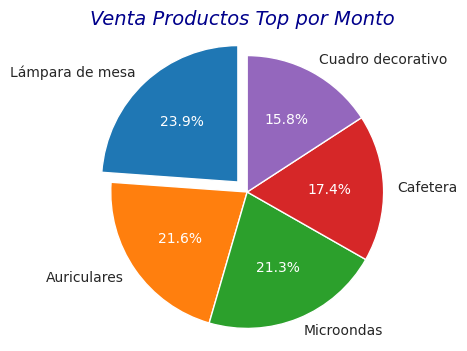

In [253]:
# @title
ganancia_cm = ganancia_con_market.sort_values(by='margen_neto', ascending=False).head(5)
print(len(ganancia_cm))

# PRODUCTOS TOP POR MONTO
import seaborn as sns
import matplotlib.pyplot as plt

# Crear el gráfico de torta
plt.figure(figsize=(4, 4))
sns.set_style("whitegrid")

explode = [0.1, 0,0,0,0]

# The original 'explode' variable from a previous cell had 8 elements.
# 'prod_top_cant' has 7 products (check prod_top_cant.shape[0] or len(prod_top_cant)).
# So, 'explode' must have a length of 7 to match.
#explode = [0.1] + [0] * (len(ganancia_con_market) - 1)
#explode = [0.1] + [0] * (4)

# ['prod_gener'] = "producto" en la otra tabla
wedges, texts, autotexts = plt.pie(ganancia_cm['margen_neto'], labels=ganancia_cm['producto'],
                                   autopct='%1.1f%%', explode=explode, startangle=90)

# Cambiar los atributos del título
plt.title('Venta Productos Top por Monto', fontsize=14, color='darkblue', style='italic')

plt.axis('equal')  # Equal aspect ratio ensures that pie is drawn as a circle.

# Cambiar el color de los porcentajes a blanco
for autotext in autotexts:
    autotext.set_color('white')

plt.show()


In [ ]:
# Filtrar df_ventas_market pars ver solamente  ventas_sin_marketing
ventas_sin_market = df_ventas_market[df_ventas_market['dentro_camp'] == 0]
ventas_sin_market

In [256]:
# Group by 'producto' and sum the 'margen_neto_marketing' column
#productos_margen_neto
ganancia_sin_market = ventas_sin_market.groupby('producto', as_index=False)['margen_neto'].sum()

# ordenados por producto
display(ganancia_sin_market.head() )

,producto,margen_neto
0,Adorno de pared,33055.59
1,Alfombra,27735.03
2,Aspiradora,34065.35
3,Auriculares,51612.29
4,Batidora,31710.67


ARREGLAR !!

In [263]:
ventas_con_sin_marketing = pd.merge(ganancia_con_market, ganancia_sin_market, on="producto", how="inner")

#ventas_con_sin_marketing = ventas_con_sin_marketing.sort_values(by=["ventas_producto_cm"], ascending=False)

ventas_con_sin_marketing.head()


KeyError: 'ventas_producto_cm'

In [261]:
# Transformar a formato largo
df_long = ventas_con_sin_marketing[["producto","ganancia_con_market", "ganancia_sin_market"]]
df_long = df_long.melt(id_vars="producto",
                        var_name="modalidad",
                        value_name="valores")

# df_long = df_long.sort_values(by=["valores", "modalidad"], ascending=True)
df_long.head()

KeyError: "['ganancia_con_market', 'ganancia_sin_market'] not in index"

## Graficar comparativa con y sin marketing

In [ ]:
# Estilo y paleta
sns.set_theme(               # set_theme combina estilo + contexto + paleta
    style="whitegrid",       # opciones: 'white', 'whitegrid', 'dark', 'darkgrid', 'ticks'
    context="notebook",          # escala general: 'paper', 'notebook', 'talk', 'poster'
    palette="tab10"           # paleta de colores base: "deep", "muted", "pastel" / Set1, Set2, Set3
)

plt.figure(figsize=(9,5))

colores = sns.color_palette('tab10').as_hex()
colores[0] = '#2ca02c'
colores[1] = '#ffb366'
#sns.palplot(sns.color_palette(colores))

sns.set_theme( style="whitegrid", palette=sns.color_palette(colores))

sns.barplot(data=df_long, x="producto", y="valores", hue="modalidad", width=0.8)

# sns.barplot(data=df_long, x="Trimestre", y="Ventas", hue="Producto", width=0.8)
#Invertimos Productos por Trimestre

# Ticks (valores de eje)
plt.xticks(rotation=90, fontsize=8)
plt.yticks(fontsize=8)

# Ajustes de título y ejes
plt.title('\nVentas totales por productos dentro y fuera de campaña', fontsize=14)
plt.xlabel('Productos')
plt.ylabel('Ventas')

# Obtener handles (cuadritos de color) y labels originales del gráfico
handles, labels = plt.gca().get_legend_handles_labels()

# Reemplazar solo los textos de la leyenda, manteniendo colores
plt.legend(
    handles,
    ["Fuera de campaña", "Dentro de campaña"],
    title="Modalidad",
    fontsize=9,
    title_fontsize=10
)
plt.tight_layout()
plt.show()


##

# ====================================================

## Guardamos los dataframe en uso...

In [ ]:
# Guardamos df_ventas_market
df_ventas_market.to_csv('df_ventas_market.csv')

In [ ]:
# Guardamos df_marketing
df_marketing.to_csv('df_marketing.csv')


In [ ]:
# Guardamos df_aLista_prod
#df_producto.to_csv('df_aLista_prod.csv', index=True)

.  

===============================================================================

A PARTIR DE ACA EL REPROCESAMIENTO DE VENTAS Y MARKETING


In [208]:
df_ventas_market.info()

<class 'pandas.core.frame.DataFrame'>
Index: 2998 entries, 1476 to 744
Data columns (total 16 columns):
 #   Column        Non-Null Count  Dtype         
---  ------        --------------  -----         
 0   id_venta      2998 non-null   int64         
 1   id_prod       2998 non-null   int64         
 2   id_producto   2998 non-null   int64         
 3   producto      2998 non-null   object        
 4   rango         2998 non-null   object        
 5   precio_unit   2998 non-null   float64       
 6   cantidad      2998 non-null   int64         
 7   fecha_venta   2998 non-null   datetime64[ns]
 8   id_cat        2998 non-null   int64         
 9   categoria     2998 non-null   object        
 10  precio_rango  2998 non-null   object        
 11  dentro_camp   2998 non-null   int64         
 12  id_camp       2998 non-null   int64         
 13  canal         2998 non-null   object        
 14  costo_mrkt    2998 non-null   float64       
 15  id_canal      2998 non-null   int64      

In [ ]:
df_ventas_market.head(100)